In [2]:
import legume

import numpy as np
import matplotlib.pyplot as plt
import time

import autograd.numpy as npa
from autograd import grad, value_and_grad

import legume
from legume.minimize import Minimize

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# ── Physical parameters ─────────────────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)

# PhC cavity simulation

Bandgap: 0.2489 – 0.3274,  centre f_target = 0.2882


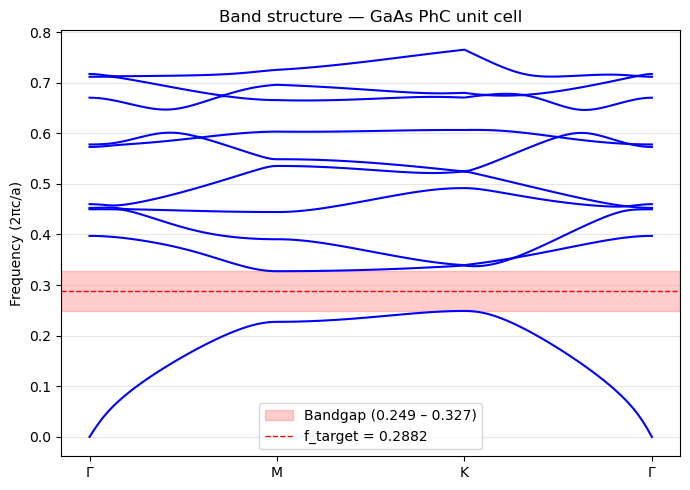

In [4]:
# ── Band structure of the perfect PhC (unit cell) ──────────────────────────
lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(legume.Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f"Bandgap: {f_lb:.4f} – {f_ub:.4f},  centre f_target = {f_target:.4f}")

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} – {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['Γ', 'M', 'K', 'Γ'])
ax.set_ylabel('Frequency (2πc/a)')
ax.set_title('Band structure — GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: xlabel='Wave vector', ylabel='Frequency $\\omega a /(2\\pi c)$'>

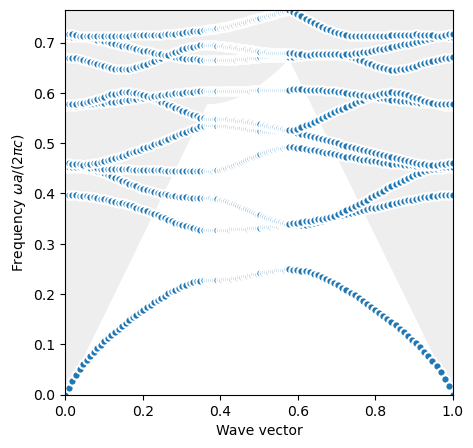

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
legume.viz.bands(gme_bands, ax=ax, k_units=True, Q=False)

In [6]:
# Number of PhC periods in x and y directions
Nx, Ny = 16, 10

# Initialize a lattice and PhC
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Make x and y positions in one quadrant of the supercell
# We only initialize one quadrant because we want to shift the holes symmetrically
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        # Skip the 3 L3 cavity holes:
        #   (ix=0, iy=0) → origin hole (1 hole)
        #   (ix=1, iy=0) → (1,0) and its (-1,0) mirror (2 holes)
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Initialize shift parameters to zeros
dx, dy = np.zeros((nc,)), np.zeros((nc,))

In [7]:

# Define L3 PhC cavity with shifted holes
def cavity(dx, dy):
    # Initialize PhC
    phc = legume.PhotCryst(lattice)

    # Add a layer to the PhC
    phc.add_layer(d=dslab, eps_b=n_slab**2)

    # Apply holes symmetrically in the four quadrants
    for ic, x in enumerate(xp):
        yc = yp[ic] if yp[ic] == 0 else yp[ic] + dy[ic]
        xc = x if x == 0 else xp[ic] + dx[ic]
        phc.add_shape(legume.Circle(x_cent=xc, y_cent=yc, r=ra))
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=-yc, r=ra))
        if nx-1.6 > xp[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=yc, r=ra))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            phc.add_shape(legume.Circle(x_cent=xc, y_cent=-yc, r=ra))

    return phc


In [8]:
# Solve for a cavity defined by shifts dx, dy
def gme_cavity(dx, dy, gmax, truncate_g, options):
    # Initialize PhC
    phc = cavity(dx, dy)

    # For speed, we don't want to compute the loss rates of *all* modes that we store
    options['compute_im'] = False

    # Initialize GME
    gme = legume.GuidedModeExp(phc, gmax=gmax, truncate_g=truncate_g)

    # Solve for the real part of the frequencies
    gme.run(kpoints=np.array([[0], [0]]), **options)

    # Find the imaginary frequency of the fundamental cavity mode
    (freq_im, _, _) = gme.compute_rad(0, [mode_idx])

    # Finally, compute the quality factor
    Q = gme.freqs[0, mode_idx]/2/freq_im[0]
    return (gme, Q)

In [9]:
gmax = 2
truncate_g = 'tbt'  # for large rectangular supercells better to use tbt, it is faster and uses less memory
options = {'gmode_inds': [0], 'verbose': True, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx'}

# Run GME directly for the initial mode-identification pass
phc_init = cavity(dx, dy)
gme = legume.GuidedModeExp(phc_init, gmax=gmax, truncate_g=truncate_g)
gme.run(kpoints=np.array([[0], [0]]), **{**options, 'compute_im': False})

# Identify the L3 cavity mode (first mode inside the bandgap)
print(f"\nModes near bandgap centre (bandgap: {f_lb:.4f} – {f_ub:.4f}):")
mode_idx = None
for i in range(gme.freqs.shape[1]):
    (freq_im_i, _, _) = gme.compute_rad(0, [i])
    Qi = gme.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme.freqs[0, i] < f_ub
    tag = " <-- cavity mode (IN BANDGAP)" if in_gap else ""
    print(f"  Mode {i}: f = {gme.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}")
    if in_gap and mode_idx is None:
        mode_idx = i

if mode_idx is None:
    raise RuntimeError("No mode found inside the bandgap — check f_lb/f_ub or increase numeig")
print(f"\nUsing mode_idx = {mode_idx}")

# Compute Q for the identified cavity mode
(freq_im, _, _) = gme.compute_rad(0, [mode_idx])
Q = gme.freqs[0, mode_idx] / (2 * freq_im[0])

74.916s total time for real part of frequencies in GuidedModeExp, of which
  0.167s (0%) for guided modes computation using the gmode_compute='exact' method
  2.412s (3%) for inverse matrix of Fourier-space permittivity
  70.073s (94%) for matrix diagionalization using the 'eigh' solver
  2.264s (3%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes

Modes near bandgap centre (bandgap: 0.2489 – 0.3274):
  Mode 0: f = 0.25966,  Q = 6343.7 <-- cavity mode (IN BANDGAP)
  Mode 1: f = 0.27965,  Q = 685.3 <-- cavity mode (IN BANDGAP)
  Mode 2: f = 0.28005,  Q = 557.2 <-- cavity mode (IN BANDGAP)
  Mode 3: f = 0.28180,  Q = 253.3 <-- cavity mode (IN BANDGAP)
  Mode 4: f = 0.28392,  Q = 288.5 <-- cavity mode (IN BANDGAP)
  Mode 5: f = 0.30953,  Q = 686.8 <-- cavity mode (IN BANDGAP)
  Mode 6: f = 0.32352,  Q = 5108.6 <-- cavity mode (IN BANDGAP)
  Mode 7: f = 0.32648,  Q = 781863.3 <-- cav

Cavity quality factor: 6343.69


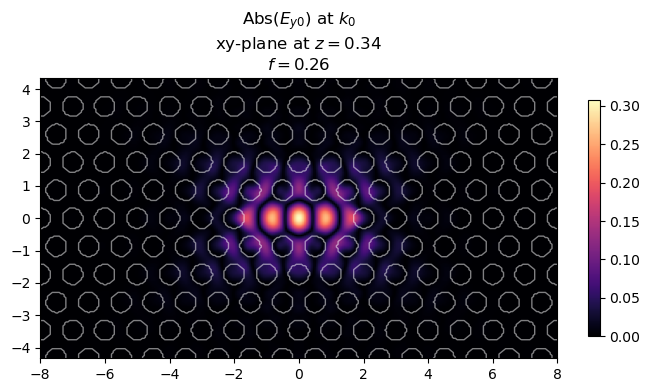

In [10]:
# Print the computed quality factor
print("Cavity quality factor: %1.2f" %Q)

# We can also visualize the cavity and the mode profile of the fundamental mode
ax = legume.viz.field(gme, 'e', 0, mode_idx, z=dslab/2, component='y', val='abs', N1=300, N2=200)

## Numerical Convergence Tests
Sweep `gmax`, supercell size `(Nx, Ny)`, `numeig`, and `gmode_inds` to verify the simulation parameters produce converged Q factors and cavity frequencies.

In [11]:
def run_convergence_test(Nx_t, Ny_t, gmax_t, numeig_t, gmode_inds_t,
                         ra_t=ra, dslab_t=dslab, n_slab_t=n_slab,
                         f_target_t=f_target, f_lb_t=f_lb, f_ub_t=f_ub):
    """Run a single L3 cavity simulation and return (Q, freq) for convergence testing."""
    # Build supercell lattice
    lat = legume.Lattice([Nx_t, 0], [0, Ny_t * np.sqrt(3) / 2])

    # Build hole positions in one quadrant (skipping L3 defect holes)
    xp_t, yp_t = [], []
    nx_t, ny_t = Nx_t // 2 + 1, Ny_t // 2 + 1
    for iy in range(ny_t):
        for ix in range(nx_t):
            if iy == 0 and ix in (0, 1):
                continue
            xp_t.append(ix + (iy % 2) * 0.5)
            yp_t.append(iy * np.sqrt(3) / 2)

    # Build PhC with symmetric holes in four quadrants
    phc = legume.PhotCryst(lat)
    phc.add_layer(d=dslab_t, eps_b=n_slab_t**2)
    for ic, x in enumerate(xp_t):
        yc = yp_t[ic]
        xc = x
        phc.add_shape(legume.Circle(x_cent=xc, y_cent=yc, r=ra_t))
        if nx_t - 0.6 > xp_t[ic] > 0 and (ny_t - 1.1) * np.sqrt(3) / 2 > yp_t[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=-yc, r=ra_t))
        if nx_t - 1.6 > xp_t[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=yc, r=ra_t))
        if (ny_t - 1.1) * np.sqrt(3) / 2 > yp_t[ic] > 0 and nx_t - 1.1 > xp_t[ic]:
            phc.add_shape(legume.Circle(x_cent=xc, y_cent=-yc, r=ra_t))

    # Run GME
    gme_t = legume.GuidedModeExp(phc, gmax=gmax_t, truncate_g='tbt')
    gme_t.run(kpoints=np.array([[0], [0]]),
              gmode_inds=gmode_inds_t, verbose=False,
              numeig=numeig_t, eig_sigma=f_target_t,
              compute_im=False, gradients='approx')

    # Find first mode inside bandgap
    for i in range(gme_t.freqs.shape[1]):
        if f_lb_t < gme_t.freqs[0, i] < f_ub_t:
            (freq_im, _, _) = gme_t.compute_rad(0, [i])
            Q_t = gme_t.freqs[0, i] / (2 * freq_im[0])
            return (Q_t, float(gme_t.freqs[0, i]))
    return (None, None)

print("Convergence test helper defined.")

Convergence test helper defined.


gmax convergence sweep:
    gmax             Q        freq
  --------------------------------
     1.5        6120.9     0.25880
     2.0        6343.7     0.25966
     2.5        6595.9     0.26007
     3.0        6720.6     0.26036

  Relative change (last two): Q = 1.89%, freq = 0.1114%


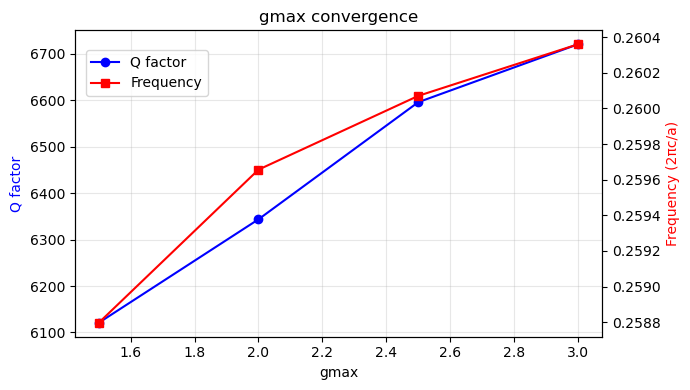

In [12]:
# --- gmax convergence ---
gmax_values = [1.5, 2.0, 2.5, 3.0]
gmax_results = []

print("gmax convergence sweep:")
print(f"  {'gmax':>6s}  {'Q':>12s}  {'freq':>10s}")
print("  " + "-" * 32)
for gm in gmax_values:
    Q_t, f_t = run_convergence_test(Nx_t=16, Ny_t=10, gmax_t=gm,
                                     numeig_t=10, gmode_inds_t=[0])
    gmax_results.append((Q_t, f_t))
    print(f"  {gm:6.1f}  {Q_t:12.1f}  {f_t:10.5f}")

# Relative change between last two values
dQ = abs(gmax_results[-1][0] - gmax_results[-2][0]) / gmax_results[-2][0] * 100
df = abs(gmax_results[-1][1] - gmax_results[-2][1]) / gmax_results[-2][1] * 100
print(f"\n  Relative change (last two): Q = {dQ:.2f}%, freq = {df:.4f}%")

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(gmax_values, [r[0] for r in gmax_results], 'bo-', lw=1.5, label='Q factor')
ax2.plot(gmax_values, [r[1] for r in gmax_results], 'rs-', lw=1.5, label='Frequency')
ax1.set_xlabel('gmax')
ax1.set_ylabel('Q factor', color='b')
ax2.set_ylabel('Frequency (2πc/a)', color='r')
ax1.set_title('gmax convergence')
ax1.grid(True, alpha=0.3)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

Supercell size convergence sweep:
     (Nx,Ny)             Q        freq
  ------------------------------------
  ( 8, 6)          6677.4     0.25975
  (12, 8)          9038.8     0.25963
  (16,10)          6343.7     0.25966
  (20,12)          8501.3     0.25963
  (24,14)          6325.8     0.25965
  (28,16)          5775.0     0.25964

  Relative change (last two): Q = 8.71%, freq = 0.0069%


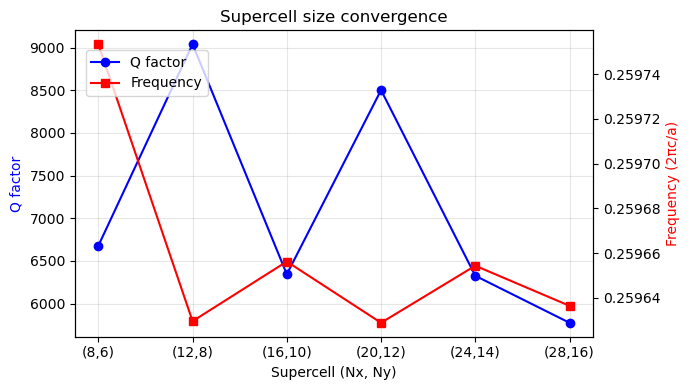

In [ ]:
# --- Supercell size convergence ---
supercell_sizes = [(8, 6), (12, 8), (16, 10), (20, 12), (24, 14), (28, 16)]
size_results = []

print("Supercell size convergence sweep:")
print(f"  {'(Nx,Ny)':>10s}  {'Q':>12s}  {'freq':>10s}")
print("  " + "-" * 36)
for (Nx_t, Ny_t) in supercell_sizes:
    Q_t, f_t = run_convergence_test(Nx_t=Nx_t, Ny_t=Ny_t, gmax_t=2.0,
                                     numeig_t=10, gmode_inds_t=[0])
    size_results.append((Q_t, f_t))
    if Q_t is not None:
        print(f"  ({Nx_t:2d},{Ny_t:2d})    {Q_t:12.1f}  {f_t:10.5f}")
    else:
        print(f"  ({Nx_t:2d},{Ny_t:2d})    {'N/A':>12s}  {'N/A':>10s}")

# Relative change between last two valid values
valid = [(Q, f) for Q, f in size_results if Q is not None]
if len(valid) >= 2:
    dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
    df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
    print(f"\n  Relative change (last two): Q = {dQ:.2f}%, freq = {df:.4f}%")

labels = [f"({n},{m})" for n, m in supercell_sizes]
valid_idx = [i for i, (Q, _) in enumerate(size_results) if Q is not None]

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(valid_idx, [size_results[i][0] for i in valid_idx], 'bo-', lw=1.5, label='Q factor')
ax2.plot(valid_idx, [size_results[i][1] for i in valid_idx], 'rs-', lw=1.5, label='Frequency')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_xlabel('Supercell (Nx, Ny)')
ax1.set_ylabel('Q factor', color='b')
ax2.set_ylabel('Frequency (2πc/a)', color='r')
ax1.set_title('Supercell size convergence')
ax1.grid(True, alpha=0.3)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

numeig convergence sweep:
    numeig             Q        freq
  ----------------------------------
         6        6343.7     0.25966
         8        6343.7     0.25966
        10        6343.7     0.25966
        15        6343.7     0.25966
        20        6343.7     0.25966

  Relative change (last two): Q = 0.00%, freq = 0.0000%


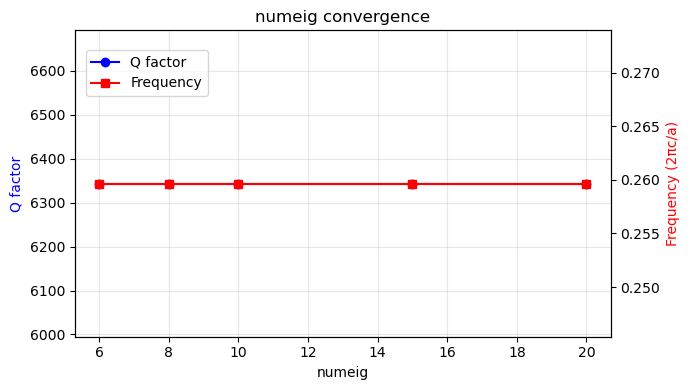

In [13]:
# --- numeig convergence ---
numeig_values = [6, 8, 10, 15, 20]
numeig_results = []

print("numeig convergence sweep:")
print(f"  {'numeig':>8s}  {'Q':>12s}  {'freq':>10s}")
print("  " + "-" * 34)
for ne in numeig_values:
    Q_t, f_t = run_convergence_test(Nx_t=16, Ny_t=10, gmax_t=2.0,
                                     numeig_t=ne, gmode_inds_t=[0])
    numeig_results.append((Q_t, f_t))
    if Q_t is not None:
        print(f"  {ne:8d}  {Q_t:12.1f}  {f_t:10.5f}")
    else:
        print(f"  {ne:8d}  {'N/A':>12s}  {'N/A':>10s}")

valid = [(Q, f) for Q, f in numeig_results if Q is not None]
if len(valid) >= 2:
    dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
    df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
    print(f"\n  Relative change (last two): Q = {dQ:.2f}%, freq = {df:.4f}%")

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
valid_ne = [numeig_values[i] for i, (Q, _) in enumerate(numeig_results) if Q is not None]
valid_Q = [Q for Q, _ in numeig_results if Q is not None]
valid_f = [f for _, f in numeig_results if f is not None]
ax1.plot(valid_ne, valid_Q, 'bo-', lw=1.5, label='Q factor')
ax2.plot(valid_ne, valid_f, 'rs-', lw=1.5, label='Frequency')
ax1.set_xlabel('numeig')
ax1.set_ylabel('Q factor', color='b')
ax2.set_ylabel('Frequency (2πc/a)', color='r')
ax1.set_title('numeig convergence')
ax1.grid(True, alpha=0.3)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

In [ ]:
# --- gmode_inds convergence ---
gmode_configs = [[0], [0, 1], [0, 1, 2]]
gmode_results = []

print("gmode_inds convergence sweep:")
print(f"  {'gmode_inds':>12s}  {'Q':>12s}  {'freq':>10s}")
print("  " + "-" * 38)
for gm_inds in gmode_configs:
    Q_t, f_t = run_convergence_test(Nx_t=16, Ny_t=10, gmax_t=2.0,
                                     numeig_t=10, gmode_inds_t=gm_inds)
    gmode_results.append((Q_t, f_t))
    label = str(gm_inds)
    if Q_t is not None:
        print(f"  {label:>12s}  {Q_t:12.1f}  {f_t:10.5f}")
    else:
        print(f"  {label:>12s}  {'N/A':>12s}  {'N/A':>10s}")

valid = [(Q, f) for Q, f in gmode_results if Q is not None]
if len(valid) >= 2:
    dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
    df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
    print(f"\n  Relative change (last two): Q = {dQ:.2f}%, freq = {df:.4f}%")

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
valid_Q = [Q for Q, _ in gmode_results if Q is not None]
valid_f = [f for _, f in gmode_results if f is not None]
x_pos = list(range(len(valid_Q)))
ax1.plot(x_pos, valid_Q, 'bo-', lw=1.5, label='Q factor')
ax2.plot(x_pos, valid_f, 'rs-', lw=1.5, label='Frequency')
ax1.set_xticks(range(len(gmode_configs)))
ax1.set_xticklabels([str(g) for g in gmode_configs])
ax1.set_xlabel('gmode_inds')
ax1.set_ylabel('Q factor', color='b')
ax2.set_ylabel('Frequency (2πc/a)', color='r')
ax1.set_title('gmode_inds convergence')
ax1.grid(True, alpha=0.3)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

gmode_inds convergence sweep:
    gmode_inds             Q        freq
  --------------------------------------
           [0]        6343.7     0.25966
        [0, 1]          56.4     0.28396


KeyboardInterrupt: 

In [ ]:
# --- Convergence summary ---
THRESHOLD = 5.0  # percent

def rel_change(results):
    """Relative change (%) between last two valid (Q, freq) pairs."""
    valid = [(Q, f) for Q, f in results if Q is not None]
    if len(valid) < 2:
        return None, None
    dQ = abs(valid[-1][0] - valid[-2][0]) / valid[-2][0] * 100
    df = abs(valid[-1][1] - valid[-2][1]) / valid[-2][1] * 100
    return dQ, df

sweeps = {
    'gmax':        gmax_results,
    'supercell':   size_results,
    'numeig':      numeig_results,
    'gmode_inds':  gmode_results,
}

print("=" * 58)
print("  CONVERGENCE SUMMARY")
print("=" * 58)
print(f"  {'Parameter':>12s}  {'dQ (%)':>10s}  {'df (%)':>10s}  {'Status':>10s}")
print("  " + "-" * 46)

all_pass = True
for name, results in sweeps.items():
    dQ, df = rel_change(results)
    if dQ is None:
        status = "NO DATA"
        all_pass = False
    elif dQ > THRESHOLD or df > THRESHOLD:
        status = "WARN"
        all_pass = False
    else:
        status = "OK"
    dQ_str = f"{dQ:.2f}" if dQ is not None else "N/A"
    df_str = f"{df:.4f}" if df is not None else "N/A"
    print(f"  {name:>12s}  {dQ_str:>10s}  {df_str:>10s}  {status:>10s}")

print("  " + "-" * 46)
if all_pass:
    print("  All parameters converged (< 5% change between last two values).")
else:
    print("  WARNING: Some parameters show >5% change — consider increasing them.")

## Autograd backend

In [33]:
# To compute gradients, we need to set the `legume` backend to 'autograd'
legume.set_backend('autograd')

# Set GME options — use eig_sigma so the solver targets modes near the bandgap centre
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx'}

# Define an objective function: only optimize the symmetric x-shift of the two end holes
# (ic=0, xp=2.0, yp=0) — Akahane et al. end-hole shift
def of_Q(params):
    # params[0] = x-shift of the two end holes adjacent to the L3 cavity
    dx_full = npa.concatenate([params[0:1], npa.zeros(nc - 1)])
    dy_full = npa.zeros(nc)
    (gme, Q) = gme_cavity(dx_full, dy_full, gmax=gmax, truncate_g=truncate_g, options=options)

    # We put a negative sign because we use in-built methods to *minimize* the objective function
    return -Q

## Test gradient of quality factor

In [34]:
# The autograd function `value_and_grad` returns simultaneously the objective value and the gradient
obj_grad = value_and_grad(of_Q)

# We do the numerical check w.r.t. the end-hole shift (the only parameter)
ind0 = 0
# We set the starting parameter to zero, i.e. un-modified cavity
pstart = np.zeros((1,))

# Compute the autograd gradients (NB: all at once!)
t = time.time()
grad_a = obj_grad(pstart)[1]
# Print the gradient w.r.t. the parameter index ind0
print("Autograd gradient:  %1.4f, computed in %1.4fs" %(grad_a[ind0], time.time() - t))

# Compute a numerical gradient for one selected index
t = time.time()
p_test = np.copy(pstart)
p_test[ind0] = p_test[ind0] + 1e-5
grad_n = (of_Q(p_test) - of_Q(pstart))/1e-5
print("Numerical gradient: %1.4f, computed in %1.4fs" %(grad_n, time.time() - t))

print("Relative difference: %1.2e" %np.abs((grad_a[ind0] - grad_n)/grad_n))


Autograd gradient:  -51749.0330, computed in 17.6621s
Numerical gradient: -51752.1504, computed in 28.3814s
Relative difference: 6.02e-05


## test gradient of fields

In [35]:
# Define an objective function which is proportional to the V of the fundamental mode
def of_V(params):
    dx = params[0:nc]
    dy = params[nc:]
    (gme, Q) = gme_cavity(dx, dy, gmax=gmax, truncate_g=truncate_g, options=options)

    # Get the electric field in the center of the slab
    Ey = gme.get_field_xy('e', kind=0, mind=mode_idx, z=dslab/2, component='y', Nx=3, Ny=3)[0]['y']

    # Notice the use of autograd.numpy (npa) and not plain numpy (np)
    return 1/npa.square(npa.amax(npa.abs(Ey)))


In [36]:
# The autograd function `value_and_grad` returns simultaneously the objective value and the gradient
obj_grad = value_and_grad(of_V)

# We do the numerical check w.r.t. the closest hole to the center
ind0 = 0
# We set the starting parameters to zeros, i.e. un-modified cavity
pstart = np.zeros((2*nc, ))

# Compute the autograd gradients (NB: all at once!)
t = time.time()
grad_a = obj_grad(pstart)[1][ind0]
print("Autograd gradient:  %1.8f, computed in %1.4fs" %(grad_a, time.time() - t))

# Compute a numerical gradient for one selected index
t = time.time()
p_test = np.copy(pstart)
p_test[ind0] = p_test[ind0] + 1e-5
grad_n = (of_V(p_test) - of_V(pstart))/1e-5
print("Numerical gradient: %1.8f, computed in %1.4fs" %(grad_n, time.time() - t))

print("Relative difference: %1.2e" %np.abs((grad_a - grad_n)/grad_n))

/home/jonah/miniconda3/envs/photonics/lib/python3.12/site-packages/autograd/numpy/numpy_vjps.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  return onp.asarray(out, dtype=A_dtype)


Autograd gradient:  16.37230575, computed in 17.5939s
Numerical gradient: 16.37243750, computed in 24.4506s
Relative difference: 8.05e-06


## Q factor optimization

In [ ]:
# Initialize an optimization object
opt = Minimize(of_Q)

# Starting parameter
pstart = np.array([0.175])

# Run an 'adam' optimization
(p_opt, ofs) = opt.adam(pstart, step_size=0.02, Nepochs=20, bounds=[0, 0.25])

Epoch:    1/  20 | Duration:  16.27 secs | Objective: -1.891430e+05
Epoch:    2/  20 | Duration:  14.54 secs | Objective: -1.086461e+05
Epoch:    3/  20 | Duration:  15.50 secs | Objective: -1.525220e+05
Epoch:    4/  20 | Duration:  15.50 secs | Objective: -1.960443e+05
Epoch:    5/  20 | Duration:  15.71 secs | Objective: -1.615270e+05
Epoch:    6/  20 | Duration:  14.82 secs | Objective: -1.602149e+05
Epoch:    7/  20 | Duration:  17.14 secs | Objective: -1.844619e+05
Epoch:    8/  20 | Duration:  15.31 secs | Objective: -1.977851e+05
Epoch:    9/  20 | Duration:  15.10 secs | Objective: -1.773841e+05
Epoch:   10/  20 | Duration:  15.38 secs | Objective: -1.756710e+05
Epoch:   11/  20 | Duration:  15.82 secs | Objective: -1.929353e+05
Epoch:   12/  20 | Duration:  15.47 secs | Objective: -1.974151e+05
Epoch:   13/  20 | Duration:  19.56 secs | Objective: -1.860895e+05
Epoch:   14/  20 | Duration:  16.51 secs | Objective: -1.832314e+05
Epoch:   15/  20 | Duration:  17.98 secs | Objec

Cavity quality factor: 198851.54
Optimized end-hole shift: dx[0] = 0.17964a


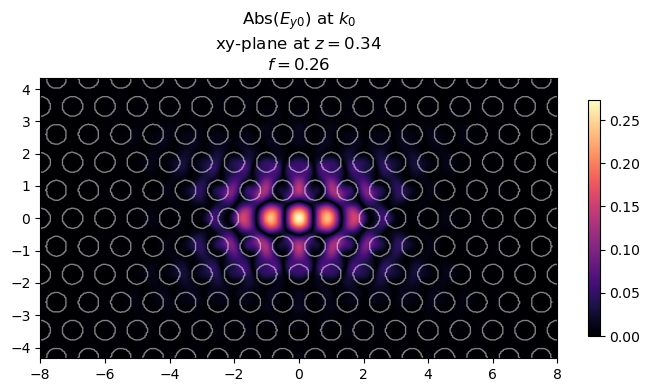

In [38]:
# Optimized parameters — end-hole shift only
dx = np.zeros(nc)
dy = np.zeros(nc)
dx[0] = float(p_opt[0])

# Run the simulation
(gme, Q) = gme_cavity(dx, dy, gmax=gmax, truncate_g=truncate_g, options=options)
print("Cavity quality factor: %1.2f" % Q)
print(f"Optimized end-hole shift: dx[0] = {float(p_opt[0]):.5f}a")
ax = legume.viz.field(gme, 'e', 0, mode_idx, z=dslab/2, component='y', val='abs', N1=400, N2=400)

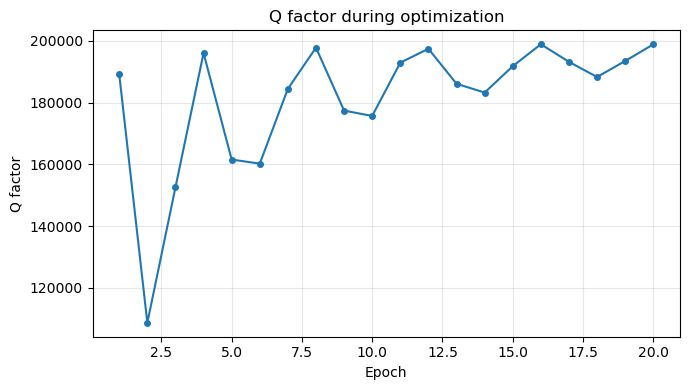

In [39]:
# Plot Q vs optimization epoch (from the ofs array returned by opt.adam)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(ofs) + 1), -np.array(ofs), 'o-', lw=1.5, markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Q factor')
ax.set_title('Q factor during optimization')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Sweeping end-hole shift:
  shift = 0.1750a,  Q = 189143.0
  shift = 0.1758a,  Q = 192150.7
  shift = 0.1766a,  Q = 194671.1
  shift = 0.1773a,  Q = 196647.0
  shift = 0.1781a,  Q = 198027.3
  shift = 0.1789a,  Q = 198769.8
  shift = 0.1797a,  Q = 198843.2
  shift = 0.1804a,  Q = 198228.7
  shift = 0.1812a,  Q = 196921.8
  shift = 0.1820a,  Q = 194932.0


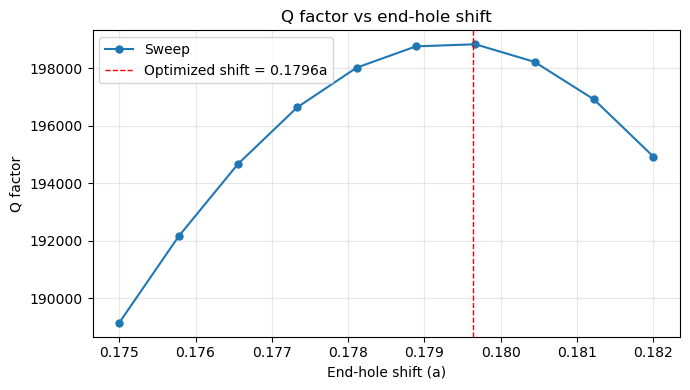

In [42]:
# Parameter sweep: Q vs end-hole shift
# Uses numpy backend for speed (no gradient overhead)
legume.set_backend('numpy')

shifts = np.linspace(0.175, 0.182, 10)
Qs_sweep = []
options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'eig_sigma': f_target, 'gradients': 'approx'}

print("Sweeping end-hole shift:")
for s in shifts:
    dx_s = np.zeros(nc); dx_s[0] = s
    dy_s = np.zeros(nc)
    (_, Q_s) = gme_cavity(dx_s, dy_s, gmax=2, truncate_g='tbt', options=options_sweep)
    Qs_sweep.append(Q_s)
    print(f"  shift = {s:.4f}a,  Q = {Q_s:.1f}")

# Plot Q vs shift, mark the optimizer result
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shifts, Qs_sweep, 'o-', lw=1.5, markersize=5, label='Sweep')
ax.axvline(float(p_opt[0]), color='red', ls='--', lw=1,
           label=f'Optimized shift = {float(p_opt[0]):.4f}a')
ax.set_xlabel('End-hole shift (a)')
ax.set_ylabel('Q factor')
ax.set_title('Q factor vs end-hole shift')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()